DANN Source Accuracy: 1.00, Target Accuracy: 0.50
Source-Only Source Accuracy: 1.00, Target Accuracy: 0.50


ValueError: 'c' argument has 500 elements, which is inconsistent with 'x' and 'y' with size 5000.

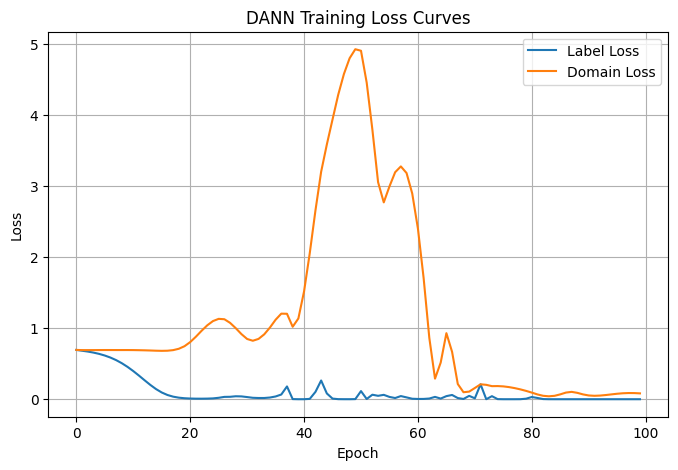

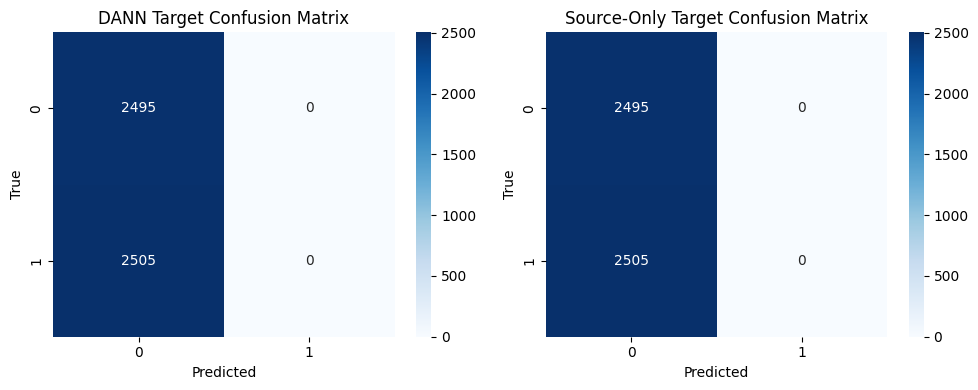

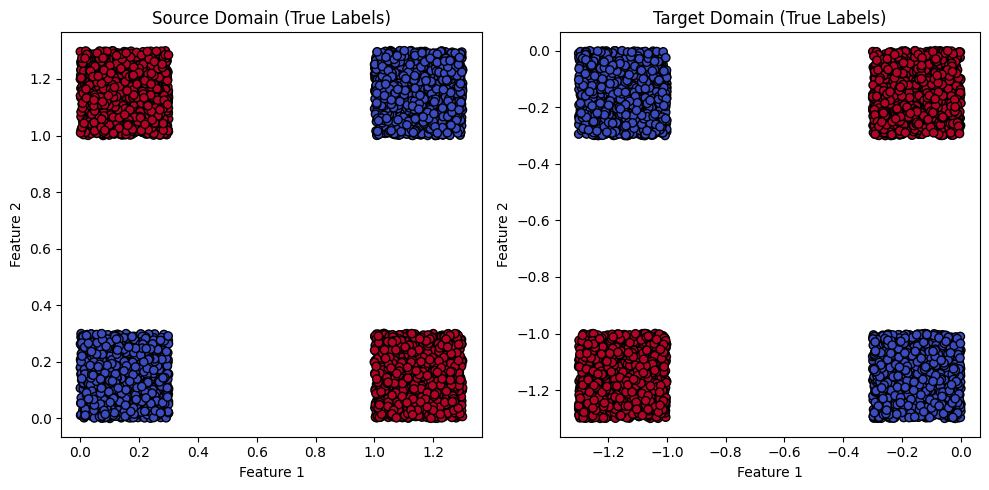

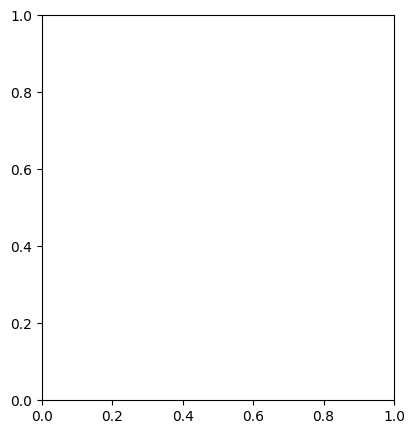

In [15]:
# this is a lost cause - hard to define the domains in a useful way here
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -----------------------------
# Fixed XOR Data Generator
# -----------------------------
def generate_xor_data(n_samples, flip: int):
    base_bits = torch.randint(0, 2, (n_samples, 2)).float()
    if flip == 1:
        y = (base_bits[:, 0] != base_bits[:, 1]).long()  # XOR labels from clean bits
    else:
        y = (base_bits[:, 0] == base_bits[:, 1]).long()  # XOR labels from clean bits
    X = base_bits + torch.rand(n_samples, 2) * 0.3  # add noise after labeling
    X = X * flip
    return X, y

# Larger dataset
X_source, y_source = generate_xor_data(5000, flip=1)
X_target, y_target = generate_xor_data(5000, flip=-1)

d_source = torch.zeros(len(X_source))
d_target = torch.ones(len(X_target))

X = torch.cat([X_source, X_target], dim=0)
y = torch.cat([y_source, y_target], dim=0)
d = torch.cat([d_source, d_target], dim=0)

# -----------------------------
# Gradient Reversal Layer
# -----------------------------
class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lamb):
        ctx.lamb = lamb
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lamb, None

class GRL(nn.Module):
    def __init__(self):
        super().__init__()
        self.lamb = 0.0

    def set_lambda(self, lamb):
        self.lamb = lamb

    def forward(self, x):
        return GradientReversal.apply(x, self.lamb)

# -----------------------------
# Larger DANN Model
# -----------------------------
class LargerDANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )
        self.label_predictor = nn.Linear(256, 2)
        self.grl = GRL()
        self.domain_classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        rev_features = self.grl(features)
        logits_label = self.label_predictor(features)
        logits_domain = self.domain_classifier(rev_features)
        return logits_label, logits_domain

# Non-DANN baseline (source-only)
class SourceOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Loss Functions
# -----------------------------
class InstanceWeightedCrossEntropyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, labels, instance_weights):
        loss = self.base_loss(logits, labels)
        masked_loss = loss * instance_weights
        return masked_loss.mean()

class InstanceWeightedCrossEntropyLoss_new(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, labels, instance_weights):
        active_mask = instance_weights > 0
        if active_mask.sum() == 0:
            return torch.tensor(0.0, device=logits.device)
        logits = logits[active_mask]
        labels = labels[active_mask]
        weights = instance_weights[active_mask]
        loss = self.base_loss(logits, labels)
        return (loss * weights).mean()

label_loss_fn = InstanceWeightedCrossEntropyLoss_new()
domain_loss_fn = nn.BCEWithLogitsLoss()

# -----------------------------
# Train DANN
# -----------------------------
dann_model = LargerDANN()
optimizer_dann = optim.Adam(dann_model.parameters(), lr=0.001)
ld_scale = 1.0
num_epochs = 100

label_losses = []
domain_losses = []

for epoch in range(num_epochs):
    lamb = 2.0 / (1.0 + np.exp(-10.0 * epoch / num_epochs)) - 1.0
    dann_model.grl.set_lambda(lamb)

    optimizer_dann.zero_grad()
    logits_label, logits_domain = dann_model(X)

    domain_mask = 1.0 - d
    loss_label = label_loss_fn(logits_label, y, domain_mask)
    loss_domain = domain_loss_fn(logits_domain.squeeze(), d)

    total_loss = loss_label + ld_scale * loss_domain
    total_loss.backward()
    optimizer_dann.step()

    label_losses.append(loss_label.item())
    domain_losses.append(loss_domain.item())

# Evaluate DANN
with torch.no_grad():
    logits_label_source, _ = dann_model(X_source)
    preds_source_dann = logits_label_source.argmax(dim=1)
    acc_source_dann = (preds_source_dann == y_source).float().mean().item()

    logits_label_target, _ = dann_model(X_target)
    preds_target_dann = logits_label_target.argmax(dim=1)
    acc_target_dann = (preds_target_dann == y_target).float().mean().item()

# -----------------------------
# Train Source-Only Model
# -----------------------------
source_model = SourceOnlyModel()
optimizer_source = optim.Adam(source_model.parameters(), lr=0.001)
loss_fn_source = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    optimizer_source.zero_grad()
    logits_source = source_model(X_source)
    loss_source = loss_fn_source(logits_source, y_source)
    loss_source.backward()
    optimizer_source.step()

# Evaluate Source-Only
with torch.no_grad():
    preds_source_only = source_model(X_source).argmax(dim=1)
    acc_source_only = (preds_source_only == y_source).float().mean().item()

    preds_target_only = source_model(X_target).argmax(dim=1)
    acc_target_only = (preds_target_only == y_target).float().mean().item()

# -----------------------------
# Results
# -----------------------------
print(f"DANN Source Accuracy: {acc_source_dann:.2f}, Target Accuracy: {acc_target_dann:.2f}")
print(f"Source-Only Source Accuracy: {acc_source_only:.2f}, Target Accuracy: {acc_target_only:.2f}")

# Plot Loss Curves for DANN
plt.figure(figsize=(8, 5))
plt.plot(label_losses, label='Label Loss')
plt.plot(domain_losses, label='Domain Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DANN Training Loss Curves')
plt.legend()
plt.grid(True)
plt.savefig('dann_loss_curves.png')

# Confusion matrices for DANN and Source-Only
cm_dann_target = confusion_matrix(y_target.numpy(), preds_target_dann.numpy())
cm_source_only_target = confusion_matrix(y_target.numpy(), preds_target_only.numpy())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm_dann_target, annot=True, fmt='d', cmap='Blues')
plt.title('DANN Target Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
sns.heatmap(cm_source_only_target, annot=True, fmt='d', cmap='Blues')
plt.title('Source-Only Target Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png')


# Scatter plots of true labels
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_source[:, 0], X_source[:, 1], c=y_source, cmap='coolwarm', edgecolor='k')
plt.title('Source Domain (True Labels)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1, 2, 2)
plt.scatter(X_target[:, 0], X_target[:, 1], c=y_target, cmap='coolwarm', edgecolor='k')
plt.title('Target Domain (True Labels)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.savefig('domain_points_true_linear_problem.png')

# Scatter plots of predicted labels
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_source[:, 0], X_source[:, 1], c=preds_source, cmap='coolwarm', edgecolor='k')
plt.title('Source Domain (Predicted Labels)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1, 2, 2)
plt.scatter(X_target[:, 0], X_target[:, 1], c=preds_target, cmap='coolwarm', edgecolor='k')
plt.title('Target Domain (Predicted Labels)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.savefig('domain_points_pred_linear_problem.png')


print("Plots saved: dann_loss_curves.png, confusion_matrices_comparison.png")